
# Algorithm for the ODE system of plasticity with combined isotropic/kinematic hardening.


1- define the model parameters, including:

- elastic modulus ($E$),
- initial yield stress ($\sigma_y=E\varepsilon_y$),
- initial kinematic hardening modulus ($C$),
- rate parameter for kinematic hardening modulus ($\gamma$),
- saturation value for isotropic hardening ($Q$),
- rate parameter for isotropic hardening ($b$)

2- define the state variables, including:
- stress ($\sigma$),
- plastic strain ($\varepsilon_{pl}$),
- plastic multiplier ($d\lambda$),
- back stress ($\chi$),
- isotropic hardening variable ($R$)

3- define the yield criteria:

$\Phi=|\sigma - \chi| - (\sigma_y + R)$ 

4- formulate the ODE system in the state-space:

 if $\Phi\leq 0$:

  $d\sigma=E d\varepsilon$

 if $\Phi > 0$:

$$ dy = \begin{bmatrix}
    d\sigma  \\
    d\varepsilon_{pl} \\
    d\lambda \\
    d\chi \\
    dR
    \end{bmatrix} =
    \begin{bmatrix}
    E(d\varepsilon - d\varepsilon_{pl})  \\
    d\lambda\text{sign}(\sigma-\chi) \\
    \Phi/ (E+C+b) \\
    Cd\varepsilon_{pl}-\gamma\chi d\lambda \\
    b(Q-R)d\lambda
    \end{bmatrix} $$
            
5- solve the ODE system of equations with an ODE solver


Note that some of the states, i.e., plastic strain and plastic multiplier, might be redundant during the solution step. However, they are presented for the sake of completeness and consistency with the conventional plasticity theories.

$$ dy = \begin{bmatrix}
    d\sigma  \\
    d\chi \\
    dR
    \end{bmatrix} =
    \begin{bmatrix}
    E(d\varepsilon - \frac{[|\sigma - \chi| - (\sigma_y + R)] \text{sign}(\sigma-\chi)}{E+C+b})  \\
    C \frac{[|\sigma - \chi| - (\sigma_y + R)] \text{sign}(\sigma-\chi)}{E+C+b} -\gamma \chi \frac{[|\sigma - \chi| - (\sigma_y + R)]}{E+C+b} \\
    b(Q-R) \frac{[|\sigma - \chi| - (\sigma_y + R)]}{E+C+b}
    \end{bmatrix} $$

Now, if we want to run it with a implicit solver (backward Euler):

$$ Y = \begin{bmatrix}
    Y_1  \\
    Y_2 \\
    Y_3 \\
    Y_4
    \end{bmatrix} =
    \begin{bmatrix}
    \sigma_{n+1} - \sigma_{n} - E(d\varepsilon - \frac{[|\sigma_{n+1} - \chi_{n+1}| - (\sigma_y + R_{n+1})] \text{sign}(\sigma_{n+1}-\chi_{n+1})}{E+C+b})  \\
    \chi_{n+1} - \chi_{n} - (C \frac{[|\sigma_{n+1} - \chi_{n+1}| - (\sigma_y + R_{n+1})] \text{sign}(\sigma_{n+1}-\chi_{n+1})}{E+C+b} -\gamma \chi_{n+1} \frac{[|\sigma_{n+1} - \chi_{n+1}| - (\sigma_y + R_{n+1})]}{E+C+b}) \\
    R_{n+1} - R_{n} - b(Q-R_{n+1}) \frac{[|\sigma_{n+1} - \chi_{n+1}| - (\sigma_y + R_{n+1})]}{E+C+b} \\
    \text{sign}(\sigma_{n+1} - \chi_{n+1}) (\sigma_{n+1} - \sigma_{n}) - \text{sign}(\sigma_{n+1} - \chi_{n+1}) (\chi_{n+1} - \chi_{n}) - (R_{n+1} - R_{n})
    \end{bmatrix} $$

You can access the generalisation in [Multiaxial Universal Plasticity Formulation](https://github.com/sinaplatform/plasticity-models/blob/main/UniversalModel3D.ipynb).


In [ ]:
# Implicit solver

import numpy as np
from numpy.linalg import solve, norm
import matplotlib.pyplot as plt

# Material parameters
E = 200e3  # Elastic modulus (MPa)
sigma_y = 150  # Initial yield stress (MPa)
C = 10000    # Kinematic hardening parameter
gamma = 20  # Back stress saturation parameter
Q = 150  # Saturation value for isotropic hardening (MPa)
b = 5  # Rate of isotropic hardening

# Sign function helper
def sign(x):
    return np.sign(x)

# Residual function
def compute_residual(x, sigma_n, chi_n, R_n, d_eps):
    sigma, chi, R, extra_var = x
    delta_sigma = sigma - sigma_n
    Xi = sigma - chi
    abs_Xi = np.abs(Xi)

    Y1 = delta_sigma - E * (d_eps - (abs_Xi - (sigma_y + R)) * sign(Xi) / (E + C + b))
    Y2 = chi - chi_n - C * ((abs_Xi - (sigma_y + R)) * sign(Xi) / (E + C + b)) - gamma * chi
    Y3 = R - R_n - b * (Q - R) * ((abs_Xi - (sigma_y + R)) / (E + C + b))
    Y4 = sign(Xi) * delta_sigma - sign(Xi) * (sigma - chi) * (chi - chi_n) - (R - R_n)

    return np.array([Y1, Y2, Y3, Y4])

# Jacobian computation (approximate using finite differences)
def compute_jacobian(x, sigma_n, chi_n, R_n, d_eps, eps=1e-8):
    J = np.zeros((4, 4))
    f0 = compute_residual(x, sigma_n, chi_n, R_n, d_eps)
    for i in range(4):
        x_perturbed = np.copy(x)
        x_perturbed[i] += eps
        f1 = compute_residual(x_perturbed, sigma_n, chi_n, R_n, d_eps)
        J[:, i] = (f1 - f0) / eps
    return J

# Newton-Raphson solver
def newton_solver(sigma_n, chi_n, R_n, d_eps, tol=1e-6, max_iter=50):
    # Initial guess
    x = np.array([sigma_n, chi_n, R_n, 0.0])

    for i in range(max_iter):
        res = compute_residual(x, sigma_n, chi_n, R_n, d_eps)
        res_norm = norm(res)
        if res_norm < tol:
            print(f"Converged in {i+1} iterations with residual norm {res_norm:.2e}")
            return x
        J = compute_jacobian(x, sigma_n, chi_n, R_n, d_eps)
        print(J, res)
        dx = solve(J, -res)
        x += dx

    print("Newton-Raphson did not converge.")
    return x

# Simulate a harmonic strain path
def simulate_harmonic_strain():
    n_steps = 100
    time = np.linspace(0, 2 * np.pi, n_steps)
    strain = 0.01 * np.sin(time)

    sigma_hist = []
    strain_hist = []

    sigma_n = 0.0
    chi_n = 0.0
    R_n = 0.0

    for i in range(1, n_steps):
        d_eps = strain[i] - strain[i - 1]
        x_new = newton_solver(sigma_n, chi_n, R_n, d_eps)
        sigma_n, chi_n, R_n, _ = x_new

        sigma_hist.append(sigma_n)
        strain_hist.append(strain[i])

    plt.plot(strain_hist, sigma_hist, label="Stress-Strain Response")
    plt.xlabel("Strain")
    plt.ylabel("Stress")
    plt.title("Hysteresis Loop - Backward Euler Solver")
    plt.legend()
    plt.grid()
    plt.show()

# Run simulation
simulate_harmonic_strain()


In [8]:
import numpy as np
from scipy.interpolate import CubicHermiteSpline
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# from ipywidgets import interact
# %matplotlib qt
# import pyqtgraph as pg
# from pyqtgraph.Qt import QtGui
# plt.rcdefaults()

# figure styling
font=18
font_axis=20
plt.rcParams.update({'font.size': font})  # Set the desired font size
# plt.rcParams['text.usetex'] = True
# plt.rcParams['figure.facecolor'] = 'white'  # Background color for figures
# plt.rcParams['axes.facecolor'] = 'white'    # Background color for axes
# Set the font to Times New Roman globally
plt.rcParams["font.family"] = "Times New Roman"
# plt.rcParams["mathtext.fontset"] = "stix"  # Use a math font for mathtext (like Greek symbols)

import multiprocessing as mp
from mpi4py import MPI
from pathlib import Path
# quick run for automated notebook validation
# dry_run = False

In [9]:
# Different loading path generation strategies 

def deformation(M, tmax, Fmax, Fscale, steps):

    t_interp = np.linspace(0, tmax, steps)
    seed=None

    if seed is not None:
        np.random.seed(seed)
        
    # Divide time interval [0, 1] into M intervals
    t = np.sort(np.random.uniform(0, 1, M))
    t = np.insert(t, 0, 0)  # Ensure t^0 = 0
    t = np.append(t, 1)      # Ensure t^M = 1

    # Initialize F_ij arrays (for i,j=1:3)
    F = np.zeros((M + 2))

    # Initialize velocity increments
    v = np.random.choice([-1, 1], size=(M + 1))  # v_ij are Rademacher variables


    for m in range(1, M + 2):
        delta_t = np.sqrt(t[m] - t[m - 1])
        F[m] = F[ m - 1] + v[m - 1] * Fmax * delta_t

    # Create interpolated paths for F_ij(t)
    interpolated_F = {}

    # Cubic Hermite spline interpolation
    spline = CubicHermiteSpline(t, F, np.gradient(F, t))
    interpolated_F = spline
    derivative_F = spline.derivative(nu=1)
    
    # Interpolate the values
    F_interp = interpolated_F(t_interp)
    F_prim = derivative_F(t_interp)

    max_value =np.max(np.abs(F_interp))
    F_interp = F_interp / max_value
    F_interp = F_interp * Fscale

    F_prim = F_prim / max_value
    F_prim = F_prim * Fscale

    return t_interp, F_interp, F_prim, t, (F / max_value) * Fscale

# Generate custom cyclic strain path (from user-provided function)
def generate_cyclic_strain(max_strain, num_cycles, points_per_cycle=100):
    """
    Generate cyclic strain history.
    """
    lcnd=np.tile([-max_strain,max_strain],num_cycles)
    lcnd=np.insert(lcnd,0,0)
    lcnd=np.insert(lcnd,1,max_strain)

    # Create arrays for strain points
    strain_history = []
    for i in range(len(lcnd)-1):
        if i==0:
            segment = np.linspace(lcnd[i], lcnd[i+1], np.int8(points_per_cycle/2))
        else:
            segment = np.linspace(lcnd[i], lcnd[i+1], points_per_cycle)
        strain_history.extend(segment[:-1])  # Exclude last point to avoid duplicates
    strain_history.append(lcnd[-1])  # Add final point
    steps = np.linspace(0, len(strain_history), len(strain_history))

    return steps, strain_history


def generate_positive_strain_path_with_trend(initial_strain, strain_increment, linear_slope, num_cycles, points_per_segment=100):
    strain = []
    
    # First segment: 0 to initial_strain
    first_segment = np.linspace(0, initial_strain, points_per_segment)[:-1]
    strain.extend(first_segment)
    
    for cycle in range(num_cycles):
        current_max = initial_strain + cycle * strain_increment
        
        # Down to zero
        down_segment = np.linspace(current_max, 0, points_per_segment)[:-1]
        strain.extend(down_segment)
        
        # Up to next max
        next_max = initial_strain + (cycle + 1) * strain_increment
        up_segment = np.linspace(0, next_max, points_per_segment)[:-1]
        strain.extend(up_segment)
    
    # Add final point
    strain.append(initial_strain + (num_cycles - 1) * strain_increment)
    
    # Add linear trend
    strain = np.array(strain)
    time = np.arange(len(strain))
    trend = linear_slope * time
    strain_with_trend = strain + trend
    steps = np.linspace(0, len(strain_with_trend), len(strain_with_trend))

    return steps, strain_with_trend

In [ ]:
# Main code to calculate the state of materials under defomation loading (deformation control)

def system_of_odes(state, strain, d_strain):
    """
    System of ODEs for combined isotropic-kinematic hardening plasticity with saturations.

    Parameters:
    - t: Time
    - state: [sigma, chi, R] (stress, back stress, isotropic hardening variable)
    - strain: Current strain at time t
    - d_strain: Current strain rate at time t
    """
    sigma, chi, R, lambda_pl, strain_pl = state

    f_yield = abs(sigma - chi) - (sigma_y + R)
    
    if f_yield < 0 or f_yield == 0:  # Elastic step
        # Stress evolves elastically
        d_sigma = E * d_strain
        d_chi = 0
        d_R = 0
        d_lambda = 0
        d_strain_pl = 0
        return [d_sigma, d_chi, d_R, d_lambda, d_strain_pl]
    elif f_yield > 0 :
        # Plastic step
        n = np.sign(sigma - chi)
        H = E + c + b

        d_lambda = f_yield / H
        d_strain_pl = d_lambda * n

        # Stress evolution
        d_sigma = E * (d_strain - d_strain_pl)
        #  stress evolution (includes decay term)
        d_chi = c * d_strain_pl - gamma * chi * d_lambda
        # Isotropic hardening evolution
        d_R = b * (Q - R) * d_lambda

        return [d_sigma, d_chi, d_R, d_lambda, d_strain_pl]
    

def append_or_save(file_path, new_data):
    file_path = Path(file_path)  # Convert to Path object

    if file_path.exists():
        existing_data = np.load(file_path)
        new_data = np.expand_dims(new_data, axis=0)
        combined_data = np.concatenate((existing_data, new_data), axis=0)
        np.save(file_path, combined_data)
    else:
        # If the file doesn't exist, expand dims and save
        new_data = np.expand_dims(new_data, axis=0)
        np.save(file_path, new_data)

# Function that wraps the computation for one iteration
def run_simulation(i):
    # Generate strain history
    time, strain_history, dstrain, t_point, strain_point = deformation(M, tmax, Fmax, Fscale, steps)
    
    strain_rate = np.diff(strain_history)  # Compute strain rate
    strain_rate = np.insert(strain_rate, 0, 0)

    # Initial state variables
    state = [0, 0, 0, 0, 0]  # [sigma, alpha, R, lambda, strain_pl]
    sigma_history, chi_history, R_history, Lambda_history, strain_pl_history = [], [], [], [], []

    # Solve for each strain step
    for j, s in enumerate(time):
        strain = strain_history[j]
        strain_rate_t = strain_rate[j]
        sol = solve_ivp(
            lambda t, y: system_of_odes(y, strain, strain_rate_t),
            [0, 1],
            state,
            method='RK45'
        )
        state = sol.y[:, -1]
        sigma_history.append(state[0])
        chi_history.append(state[1])
        R_history.append(state[2])
        Lambda_history.append(state[3])
        strain_pl_history.append(state[4])

    # Convert results to arrays
    sigma_history = np.array(sigma_history)
    chi_history = np.array(chi_history)
    R_history = np.array(R_history)
    Lambda_history = np.array(Lambda_history)
    strain_pl_history = np.array(strain_pl_history)

    # Append or save results
    append_or_save(file_time, time)
    append_or_save(file_strain, strain_history)
    append_or_save(file_stress, sigma_history)
    append_or_save(file_chi, chi_history)
    append_or_save(file_R, R_history)
    append_or_save(file_lambda, Lambda_history)
    append_or_save(file_strainpl, strain_pl_history)

    return f"Iteration {i} completed"

# Example usage
if __name__ == "__main__":

    # Material properties
    E = 200e3  # Elastic modulus (MPa)
    sigma_y = 150  # Initial yield stress (MPa)
    c = 10000    # Kinematic hardening parameter
    gamma = 20  # Back stress saturation parameter
    Q = 150  # Saturation value for isotropic hardening (MPa)
    b = 5  # Rate of isotropic hardening

    # Strain path generation parameters
    initial_strain = 0.01   # Maximum strain amplitude
    strain_increment = 0
    linear_slope = 1e-5
    num_cycles = 20         # Number of cycles
    points_per_cycle = 200  # Points per cycle

    M = 12
    Fmax = 1.0
    Fscale = 0.02
    tmax = 1
    steps = 2000

    # Generate sample discrete data
    file_time = 'time.npy'
    file_strain = 'strain.npy'
    file_stress = 'stress.npy'
    file_chi = 'chi.npy'
    file_R = 'R.npy'
    file_lambda = 'lambda.npy'
    file_strainpl = 'strainpl.npy'


    for j in range(1):  

        # Generate strain and strain rate history (activate one the below 1- cyclic, 2- augmented cyclic, 3- randomised):
        # steps, strain_history = generate_cyclic_strain(initial_strain, num_cycles, points_per_cycle)
        time, strain_history = generate_positive_strain_path_with_trend(initial_strain, strain_increment, linear_slope, num_cycles, points_per_cycle)
        # time, strain_history, dstrain, t_point, strain_point = deformation(M, tmax, Fmax, Fscale, steps)

        strain_rate = np.diff(strain_history)  # Difference between consecutive elements
        strain_rate = np.insert(strain_rate, 0, 0)

        # Initial state variables
        state = [0, 0, 0, 0, 0]  # Initial conditions: [sigma, alpha, R, lambda, strain_pl]
        sigma_history = []
        chi_history = []
        R_history = []
        Lambda_history = []
        strain_pl_history = []

        # Solve for each strain step
        for i, s in enumerate(time):
            strain = strain_history[i]
            strain_rate_t = strain_rate[i]
            sol = solve_ivp(
                lambda t, y: system_of_odes(y, strain, strain_rate_t),
                [0, 1],
                state,
                method='RK45'
            )
            state = sol.y[:, -1]
            sigma_history.append(state[0])
            chi_history.append(state[1])
            R_history.append(state[2])
            Lambda_history.append(state[3])
            strain_pl_history.append(state[4])

        # Convert results to arrays
        sigma_history = np.array(sigma_history)
        chi_history = np.array(chi_history)
        R_history = np.array(R_history)
        Lambda_history = np.array(Lambda_history)
        strain_pl_history = np.array(strain_pl_history)

        # append_or_save(file_time, time)
        # append_or_save(file_strain, strain_history)
        # append_or_save(file_stress, sigma_history)
        # append_or_save(file_chi, chi_history)
        # append_or_save(file_R, R_history)
        # append_or_save(file_lambda, Lambda_history)
        # append_or_save(file_strainpl, strain_pl_history)
 

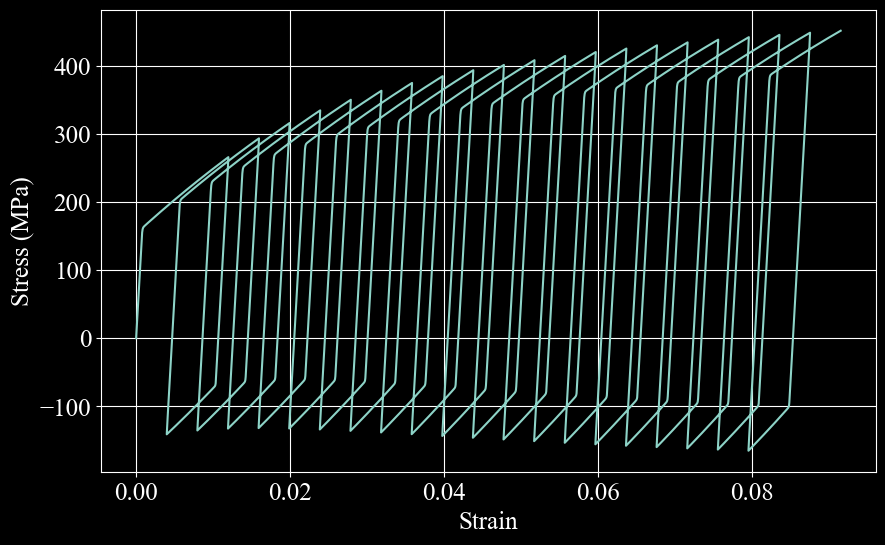

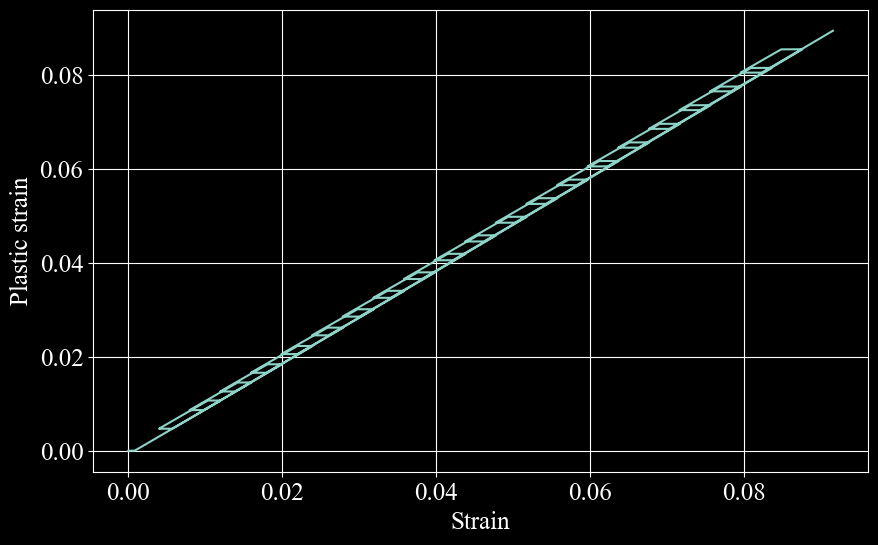

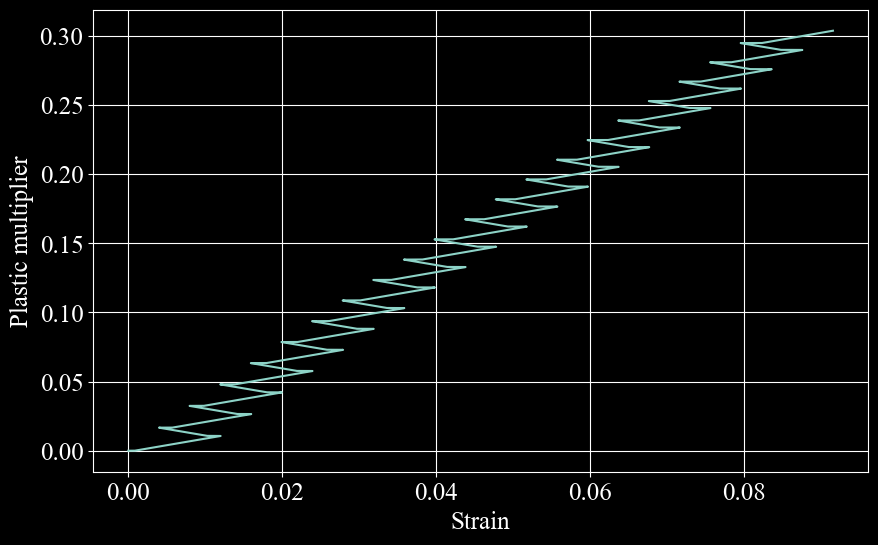

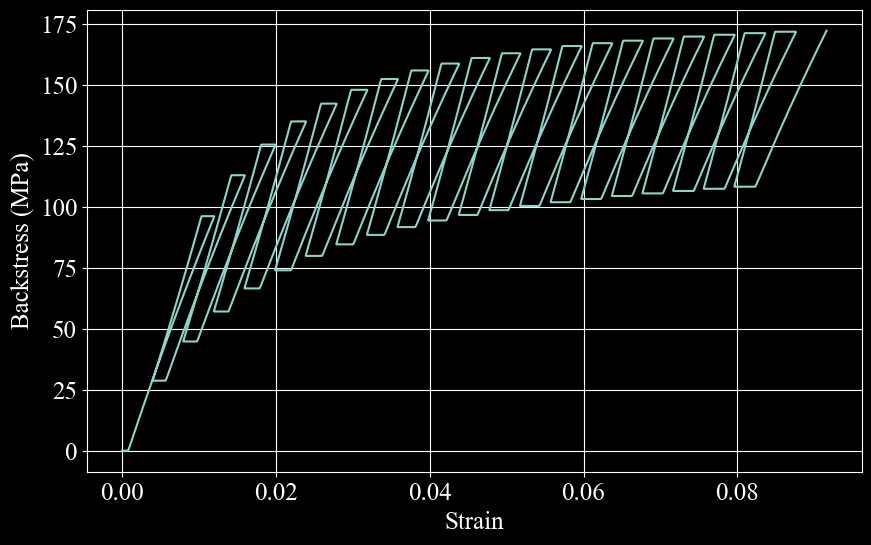

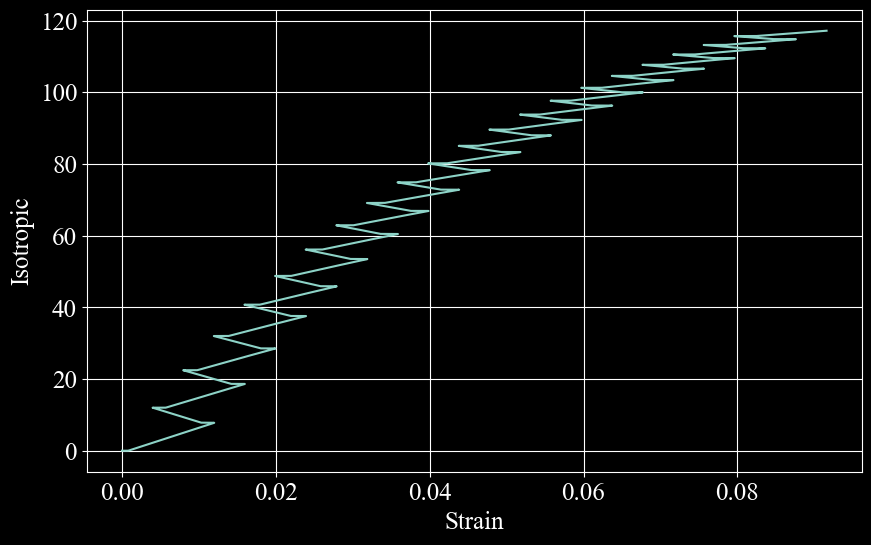

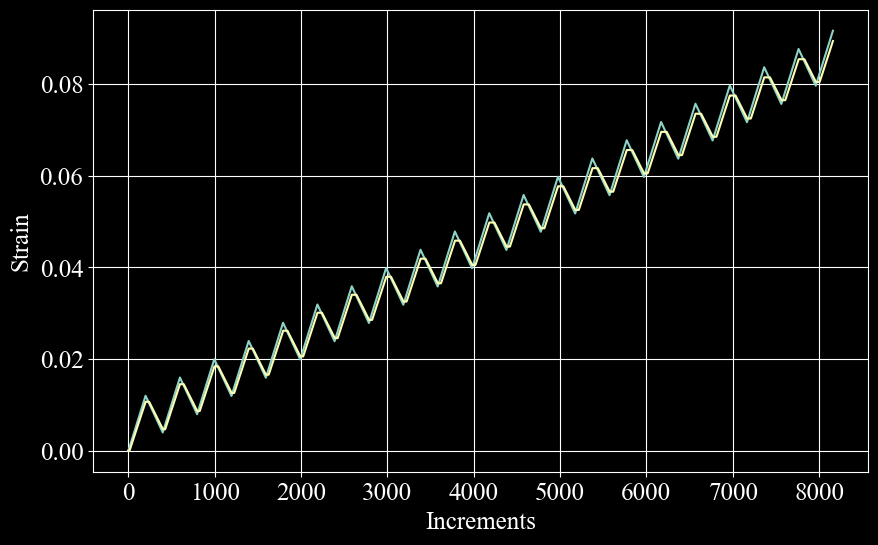

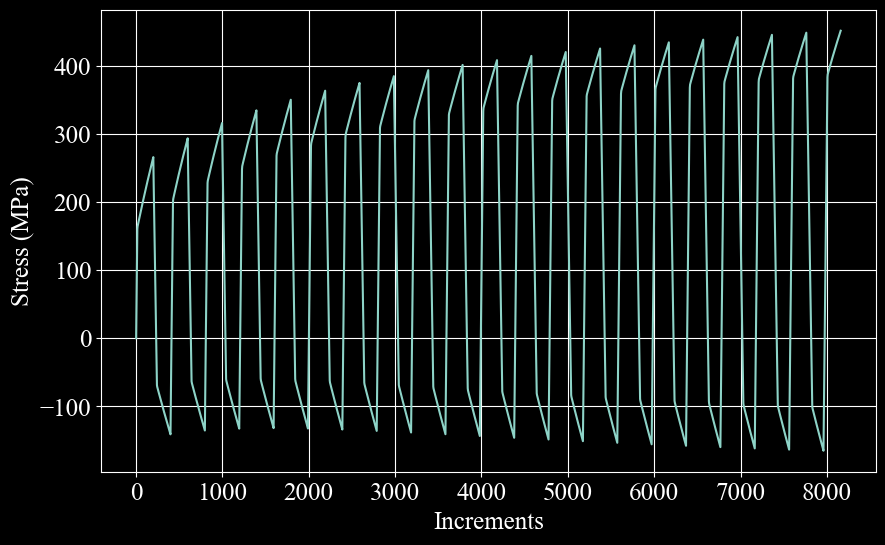

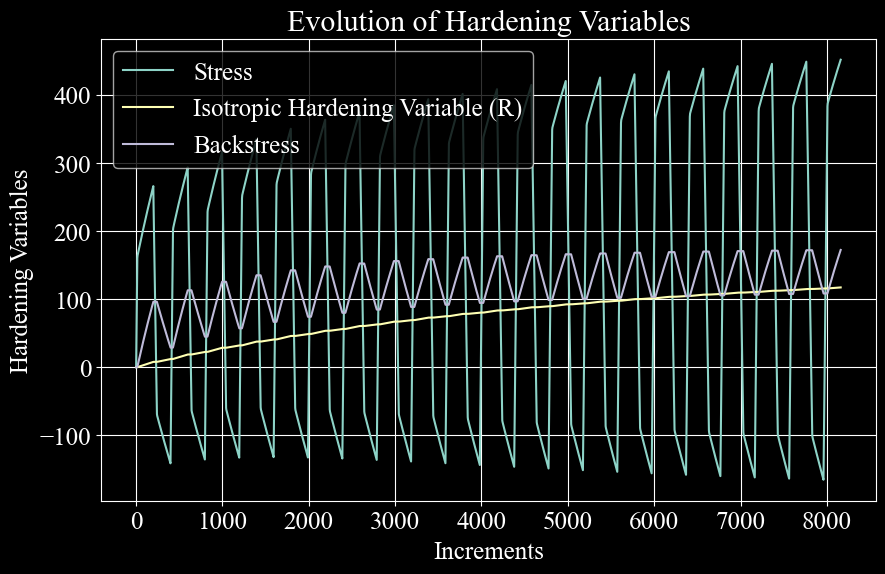

In [25]:
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(strain_history, sigma_history)
plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(strain_history, strain_pl_history)
plt.xlabel("Strain")
plt.ylabel("Plastic strain")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(strain_history, Lambda_history)
plt.xlabel("Strain")
plt.ylabel("Plastic multiplier")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(strain_history, chi_history)
plt.xlabel("Strain")
plt.ylabel("Backstress (MPa)")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(strain_history, R_history)
plt.xlabel("Strain")
plt.ylabel("Isotropic")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, strain_history)
plt.plot(time, strain_pl_history)
plt.xlabel("Increments")
plt.ylabel("Strain")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, sigma_history)
plt.xlabel("Increments")
plt.ylabel("Stress (MPa)")
plt.grid(True)
# plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, sigma_history, label="Stress")
plt.plot(time, R_history, label="Isotropic Hardening Variable (R)")
plt.plot(time, chi_history, label="Backstress")
# plt.plot(time, strain_pl_history * 1e4, label="plastic strain * 1e4")
plt.xlabel("Increments")
plt.ylabel("Hardening Variables")
plt.title("Evolution of Hardening Variables")
plt.grid(True)
plt.legend()
plt.show()